In [29]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [30]:
from dotenv import load_dotenv
from groq import Groq
from langchain.chat_models import init_chat_model
import os

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key or groq_api_key.lower() in {"your_groq_api_key", "your-api-key"}:
    raise RuntimeError(
        "Set a valid GROQ_API_KEY in the .env file before creating the chat model."
    )

groq_client = Groq(api_key=groq_api_key)
available_models = {model.id for model in groq_client.models.list().data}
preferred_models = (
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "openai/gpt-oss-20b",
)
model_name = next(
    (model for model in preferred_models if model in available_models),
    None,
)
if model_name is None:
    raise RuntimeError(
        f"This GROQ_API_KEY cannot access a supported chat model. Available models: "
        f"{sorted(available_models)}"
    )

llm = init_chat_model(
    model_name,
    model_provider="groq",
    api_key=groq_api_key,
)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000164016EF8A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016401854160>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [31]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [26]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

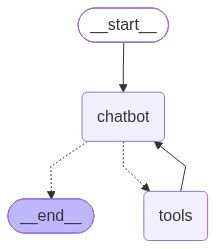

In [32]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [33]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b0539f10-84f9-487d-85b1-0fd1fcbe5199)
 Call ID: fc_b0539f10-84f9-487d-85b1-0fd1fcbe5199
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b0539f10-84f9-487d-85b1-0fd1fcbe5199)
 Call ID: fc_b0539f10-84f9-487d-85b1-0fd1fcbe5199
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?


In [34]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b0539f10-84f9-487d-85b1-0fd1fcbe5199)
 Call ID: fc_b0539f10-84f9-487d-85b1-0fd1fcbe5199
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Absolutely—our team is ready to help you build a robust AI agent. A great place to start is with **LangGraph**. It’s a modern framework designed for building scalable, reliable, and extensible agents, offering a more flexible architecture than many traditional autonomous agent libraries. If you’d like a deeper dive, a 